# Laboratorio 10: Aplicación de ICA en señales EEG

## 1. Introducción

El electroencefalograma (EEG) de superficie es una técnica no invasiva ampliamente utilizada para el estudio de la actividad eléctrica cerebral, pero está sujeta a la contaminación por artefactos biológicos (parpadeo, movimiento ocular, actividad muscular) y ambientales (interferencia de la red eléctrica), los cuales pueden solaparse en frecuencia con los ritmos cerebrales de interés y degradar la calidad del registro [1]. El Análisis de Componentes Independientes (ICA) es una técnica de separación ciega de fuentes que permite descomponer una señal observada en componentes estadísticamente independientes, y se ha consolidado como una de las herramientas más utilizadas para la identificación y remoción de artefactos en EEG [2,3].

La aplicación clásica de ICA sobre EEG asume un registro multicanal, en el que cada electrodo capta una mezcla lineal distinta de las mismas fuentes subyacentes [3]. En este laboratorio, sin embargo, la señal se adquirió con un único canal EEG real (electrodo en posición frontal FP1, configuración bipolar, dispositivo BITalino), lo cual invalida el supuesto de múltiples mezclas simultáneas necesario para una descomposición espacial de ICA convencional. Para abordar esta limitación, se adoptó una estrategia de descomposición en dos etapas: primero, la señal de un solo canal se descompuso mediante Descomposición Modal Empírica (EMD) en un conjunto de Funciones de Modo Intrínseco (IMFs) [4]; luego, estas IMFs se trataron como pseudo-canales sobre los cuales se aplicó ICA (FastICA) [5]. Esta estrategia combinada de EMD + ICA para registros de un solo canal ha sido validada previamente en la literatura como un método efectivo de separación de fuentes en ausencia de múltiples electrodos [6].

##2. Metodología

### **Adquisición de datos**

Las señales se adquirieron con un dispositivo **BITalino (r)evolution**, utilizando el sensor de Electroencefalografía (EEG) en configuración bipolar, colocado en la posición **FP1** del sistema internacional 10-20, con el electrodo de referencia en una zona ósea (mastoides, detrás de la oreja) [7]. Se registró un único canal analógico (`A4`) a una frecuencia de muestreo **FS = 100 Hz**, con una resolución del conversor analógico-digital de 10 bits, voltaje de referencia de 3.3 V y ganancia interna del sensor EEG de 1000. La conversión de cuentas ADC crudas a voltios se realizó mediante:

V = ((ADC / 2^10) − 0.5) × 3.3 / 1000

Se registraron 7 condiciones experimentales: ritmo basal 1, apertura de ojos con visión fija, ritmo basal 2 (30 s), parpadeo y masticación inducidos, ritmo basal 3 (30 s), música relajante y música estresante.

### **Preprocesamiento**

A cada registro se le aplicó un filtro pasa-banda FIR (0.5–40 Hz) mediante MNE-Python. Dado que la frecuencia de muestreo (100 Hz) fija la frecuencia de Nyquist en 50 Hz, no fue posible aplicar un filtro notch a 60 Hz según lo previsto originalmente, ya que dicha frecuencia excede el límite de Nyquist y su filtrado carece de sentido matemático sobre datos digitalizados a esta tasa [8]. Esta limitación se documenta como hallazgo metodológico y se retoma en la discusión.

### **Descomposición EMD y aplicación de ICA**

Sobre la señal filtrada de cada condición se aplicó el siguiente procedimiento:

1. **Descomposición EMD**: cada señal se descompuso en un máximo de 8 IMFs mediante el algoritmo EMD [4], implementado en la librería `PyEMD`.
2. **ICA sobre las IMFs**: el conjunto de IMFs se trató como una matriz de pseudo-canales y se aplicó **FastICA** [5], obteniendo un número de componentes independientes (IC) igual al número de IMFs disponibles por condición.
3. **Criterio de exclusión por curtosis**: se calculó la curtosis de cada componente independiente. Dado que una distribución gaussiana tiene curtosis ≈ 0 y los artefactos transitorios (parpadeos, contracciones musculares) generan distribuciones marcadamente no gaussianas, se marcaron como candidatas a artefacto las componentes con **|curtosis| > 5**, criterio consistente con el uso de estadísticos de orden superior para la detección de artefactos en componentes de ICA [9].
4. **Reconstrucción**: las componentes marcadas como artefacto se anularon antes de invertir la transformación de ICA, y la señal limpia se reconstruyó sumando las IMFs resultantes.


## Actividad 1: Cargar y visualizar las señales en el dominio temporal.

In [1]:
!pip install mne

In [2]:
# Importar librerías:
import json
import numpy as np
import mne

mne.set_log_level("WARNING")

# Constantes de conversión de ADC a Voltios
# Los datos son cuentas ADC del BITalino y deben
# convertirse a voltios usando la fórmula del datasheet del sensor EEG.
N_BITS = 10      # resolución del canal A4 (bits)
VCC = 3.3        # voltaje de referencia del BITalino (V)
G_EEG = 1000     # ganancia del sensor EEG (r)evolution

In [3]:
# Definir la función de carga que reemplaza a mne.io.read_raw_fif()
def load_opensignals_txt(filepath):

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    header_line = lines[1].lstrip("# ").strip()
    header = json.loads(header_line)
    device_key = list(header.keys())[0]
    meta = header[device_key]

    fs = meta["sampling rate"]
    columns = meta["column"]

    data_start = next(i for i, l in enumerate(lines) if "EndOfHeader" in l) + 1
    data = np.loadtxt(lines[data_start:])

    return data, columns, fs, meta

In [4]:
# Definir la función que convierte la columna A4 (cuentas ADC) a voltios
# y lo empaqueta en la estructura estándar que usa MNE para representar señales EEG.
def build_raw_real(filepath, eeg_col="A4", condition_name=None):
    """Construye un RawArray de 1 canal (la señal EEG real, en Voltios)."""
    data, columns, fs, meta = load_opensignals_txt(filepath)
    ch_idx = {c: i for i, c in enumerate(columns)}
    adc = data[:, ch_idx[eeg_col]].astype(float)
    eeg_V = (adc / (2 ** N_BITS) - 0.5) * VCC / G_EEG  # ADC -> Voltios

    info = mne.create_info(ch_names=[eeg_col], sfreq=fs, ch_types=["eeg"])
    if condition_name:
        info["description"] = condition_name
    raw = mne.io.RawArray(eeg_V[np.newaxis, :], info)
    return raw, meta

In [5]:
# Subir el archivo ritmo_basal_1.txt
from google.colab import files
uploaded = files.upload()

Saving 7_musica_estresante.txt to 7_musica_estresante.txt
Saving 1_ritmo_basal_1.txt to 1_ritmo_basal_1.txt
Saving 2_apertura_ojos_vision_fija.txt to 2_apertura_ojos_vision_fija.txt
Saving 3_ritmo_basal 2_(30seg).txt to 3_ritmo_basal 2_(30seg).txt
Saving 4_parpadeo_masticacion.txt to 4_parpadeo_masticacion.txt
Saving 5_ritmo_basal3_(30segundos).txt to 5_ritmo_basal3_(30segundos).txt
Saving 6_musica_relajante.txt to 6_musica_relajante.txt


In [6]:
filepath = "/content/1_ritmo_basal_1.txt"
raw, meta = build_raw_real(filepath, condition_name="ritmo_basal_1")
print(raw)

<RawArray | 1 x 6195 (62.0 s), ~53 KiB, data loaded>


In [8]:
from google.colab import files
uploaded = files.upload()

Saving 7_musica_estresante.txt to 7_musica_estresante (2).txt
Saving 1_ritmo_basal_1.txt to 1_ritmo_basal_1 (2).txt
Saving 2_apertura_ojos_vision_fija.txt to 2_apertura_ojos_vision_fija (2).txt
Saving 3_ritmo_basal 2_(30seg).txt to 3_ritmo_basal 2_(30seg) (2).txt
Saving 4_parpadeo_masticacion.txt to 4_parpadeo_masticacion (2).txt
Saving 5_ritmo_basal3_(30segundos).txt to 5_ritmo_basal3_(30segundos) (2).txt
Saving 6_musica_relajante.txt to 6_musica_relajante (2).txt


In [9]:
# Construir el diccionario de condiciones a partir de los archivos subidos
import os

archivos = sorted(uploaded.keys())

condiciones = {}
for nombre_archivo in archivos:
    nombre = os.path.splitext(nombre_archivo)[0]
    raw_i, meta_i = build_raw_real(nombre_archivo, condition_name=nombre)
    condiciones[nombre] = raw_i

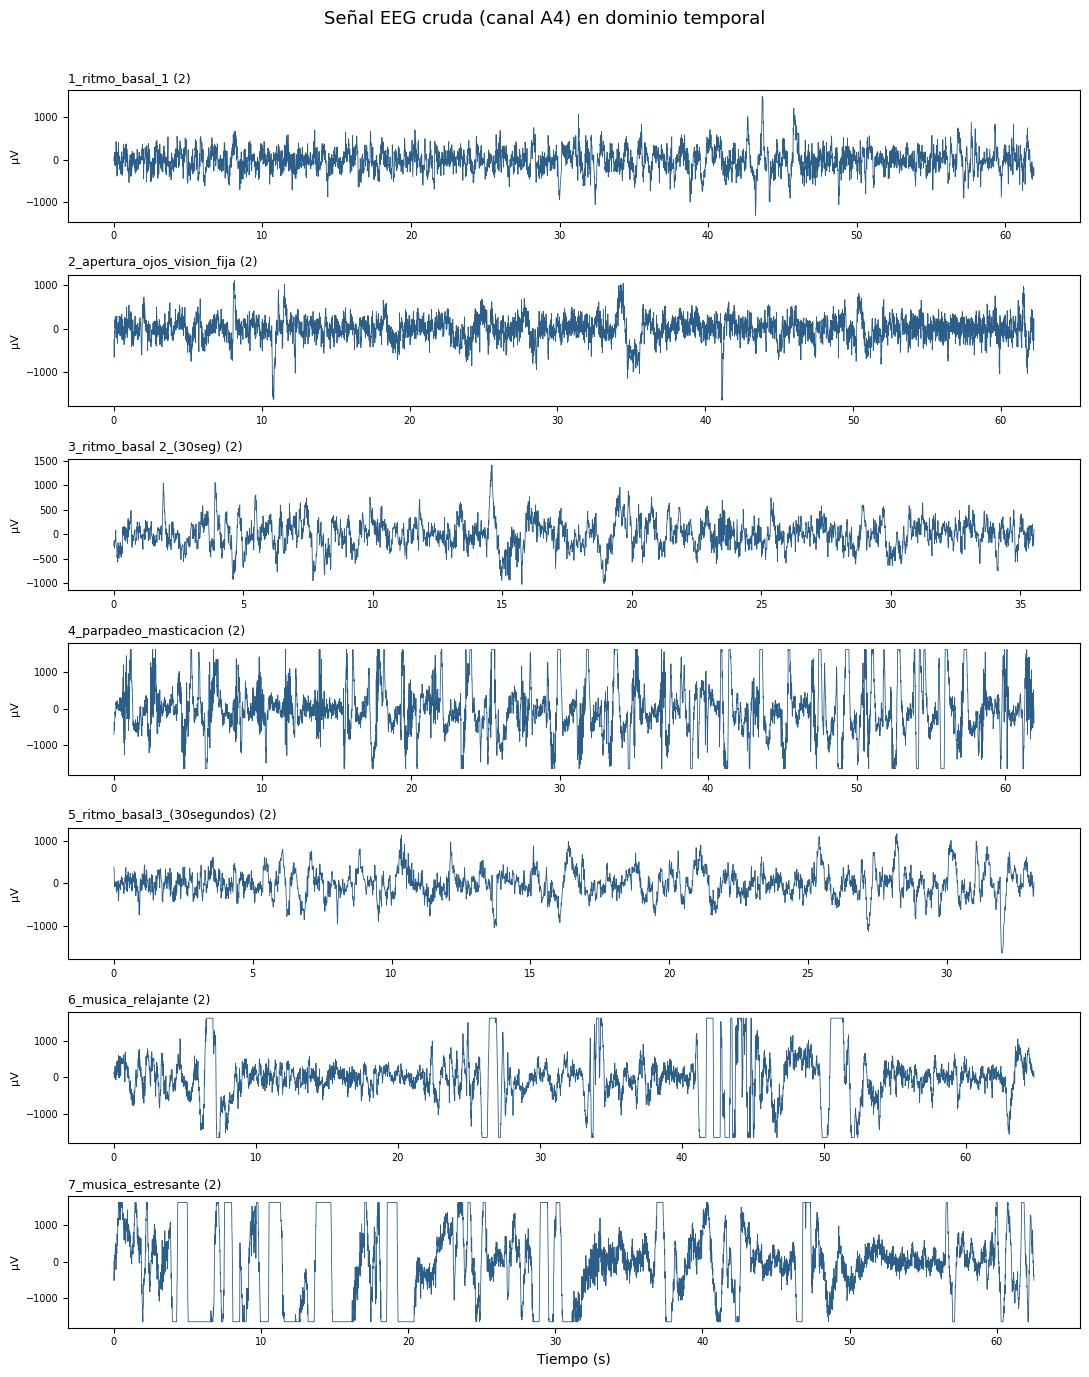

In [10]:
# Visualización temporal
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(condiciones), 1, figsize=(11, 14), sharex=False)

for ax, (nombre, raw_i) in zip(axes, condiciones.items()):
    data_uv = raw_i.get_data()[0] * 1e6  # Voltios -> microvoltios
    ax.plot(raw_i.times, data_uv, linewidth=0.6, color="#2b5f8a")
    ax.set_title(nombre, fontsize=9, loc="left")
    ax.set_ylabel("µV", fontsize=8)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel("Tiempo (s)")
fig.suptitle("Señal EEG cruda (canal A4) en dominio temporal", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [11]:
# Verificar
resumen = []
for nombre, raw_i in condiciones.items():
    resumen.append({
        "condicion": nombre,
        "duracion_s": round(raw_i.times[-1], 1),
        "fs_Hz": raw_i.info["sfreq"],
        "n_muestras": len(raw_i.times),
    })

import pprint
pprint.pprint(resumen)

[{'condicion': '1_ritmo_basal_1 (2)',
  'duracion_s': np.float64(61.9),
  'fs_Hz': 100.0,
  'n_muestras': 6195},
 {'condicion': '2_apertura_ojos_vision_fija (2)',
  'duracion_s': np.float64(62.2),
  'fs_Hz': 100.0,
  'n_muestras': 6225},
 {'condicion': '3_ritmo_basal 2_(30seg) (2)',
  'duracion_s': np.float64(35.5),
  'fs_Hz': 100.0,
  'n_muestras': 3555},
 {'condicion': '4_parpadeo_masticacion (2)',
  'duracion_s': np.float64(61.9),
  'fs_Hz': 100.0,
  'n_muestras': 6195},
 {'condicion': '5_ritmo_basal3_(30segundos) (2)',
  'duracion_s': np.float64(33.1),
  'fs_Hz': 100.0,
  'n_muestras': 3315},
 {'condicion': '6_musica_relajante (2)',
  'duracion_s': np.float64(64.8),
  'fs_Hz': 100.0,
  'n_muestras': 6480},
 {'condicion': '7_musica_estresante (2)',
  'duracion_s': np.float64(62.5),
  'fs_Hz': 100.0,
  'n_muestras': 6255}]


## Actividad 2: Aplicar preprocesamiento básico

In [12]:
# Guardar una copia de la señal cruda para comparar después
condiciones_raw = {nombre: raw_i.copy() for nombre, raw_i in condiciones.items()}

In [13]:
# Filtro pasa-banda
for nombre, raw_i in condiciones.items():
    raw_i.load_data()
    raw_i.filter(l_freq=0.5, h_freq=40.0)  # pasa-banda 0.5-40 Hz

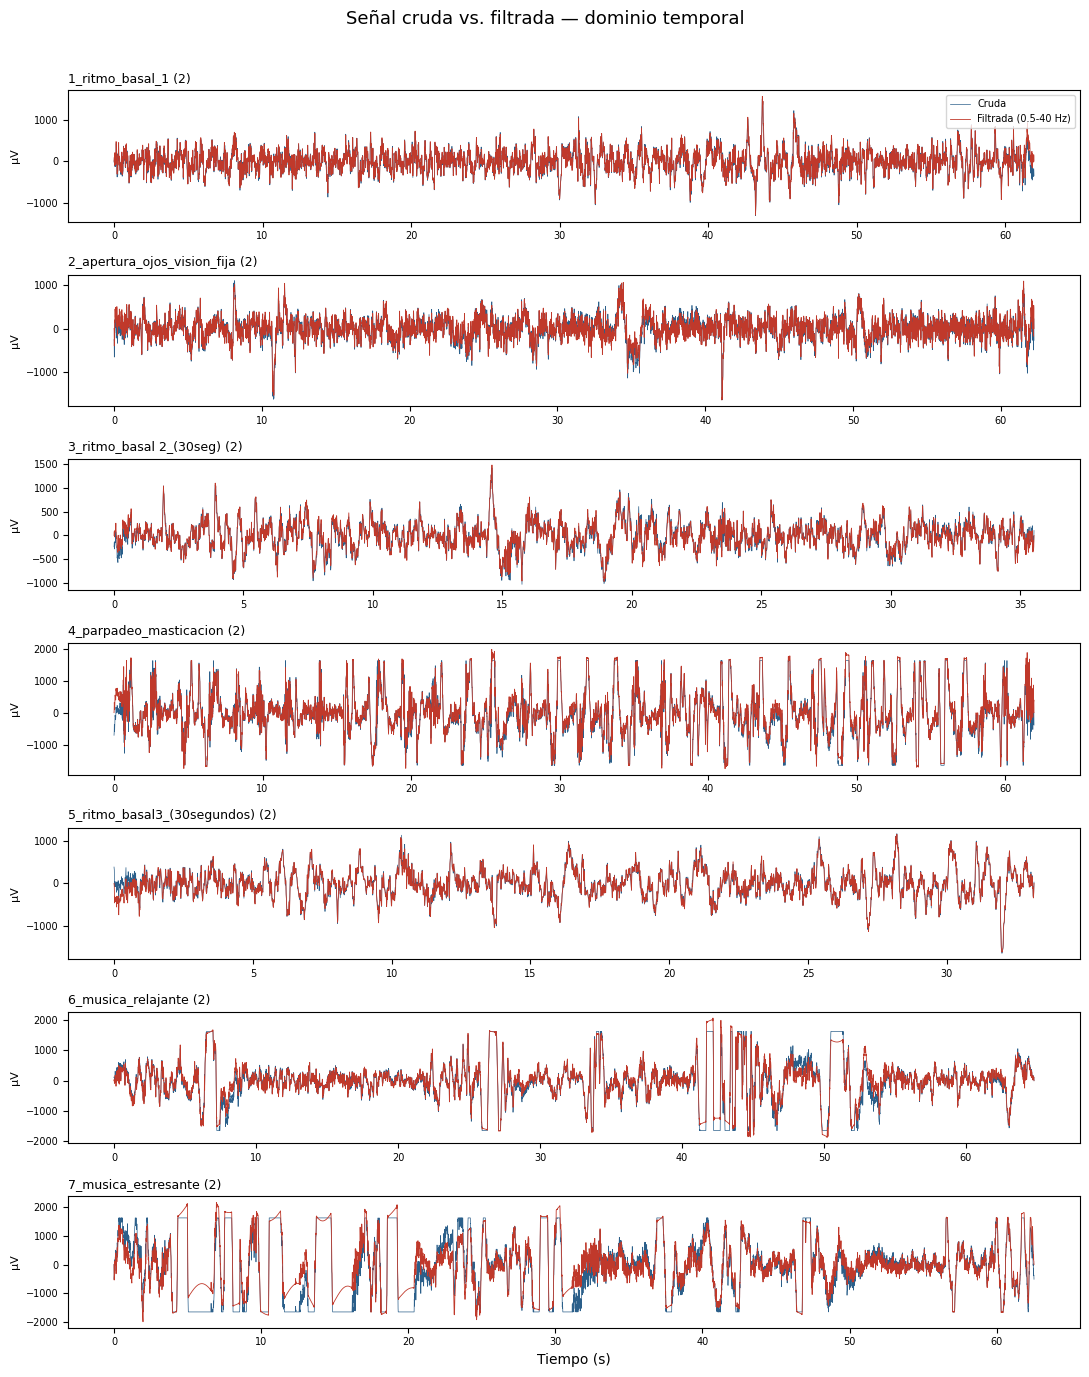

In [14]:
# Visualizar señal cruda vs. filtrada
fig, axes = plt.subplots(len(condiciones), 1, figsize=(11, 14), sharex=False)

for ax, nombre in zip(axes, condiciones.keys()):
    t = condiciones_raw[nombre].times
    cruda_uv = condiciones_raw[nombre].get_data()[0] * 1e6
    filtrada_uv = condiciones[nombre].get_data()[0] * 1e6

    ax.plot(t, cruda_uv, linewidth=0.5, color="#2b5f8a", label="Cruda")
    ax.plot(t, filtrada_uv, linewidth=0.6, color="#c0392b", label="Filtrada (0.5-40 Hz)")
    ax.set_title(nombre, fontsize=9, loc="left")
    ax.set_ylabel("µV", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].legend(loc="upper right", fontsize=7)
axes[-1].set_xlabel("Tiempo (s)")
fig.suptitle("Señal cruda vs. filtrada — dominio temporal", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

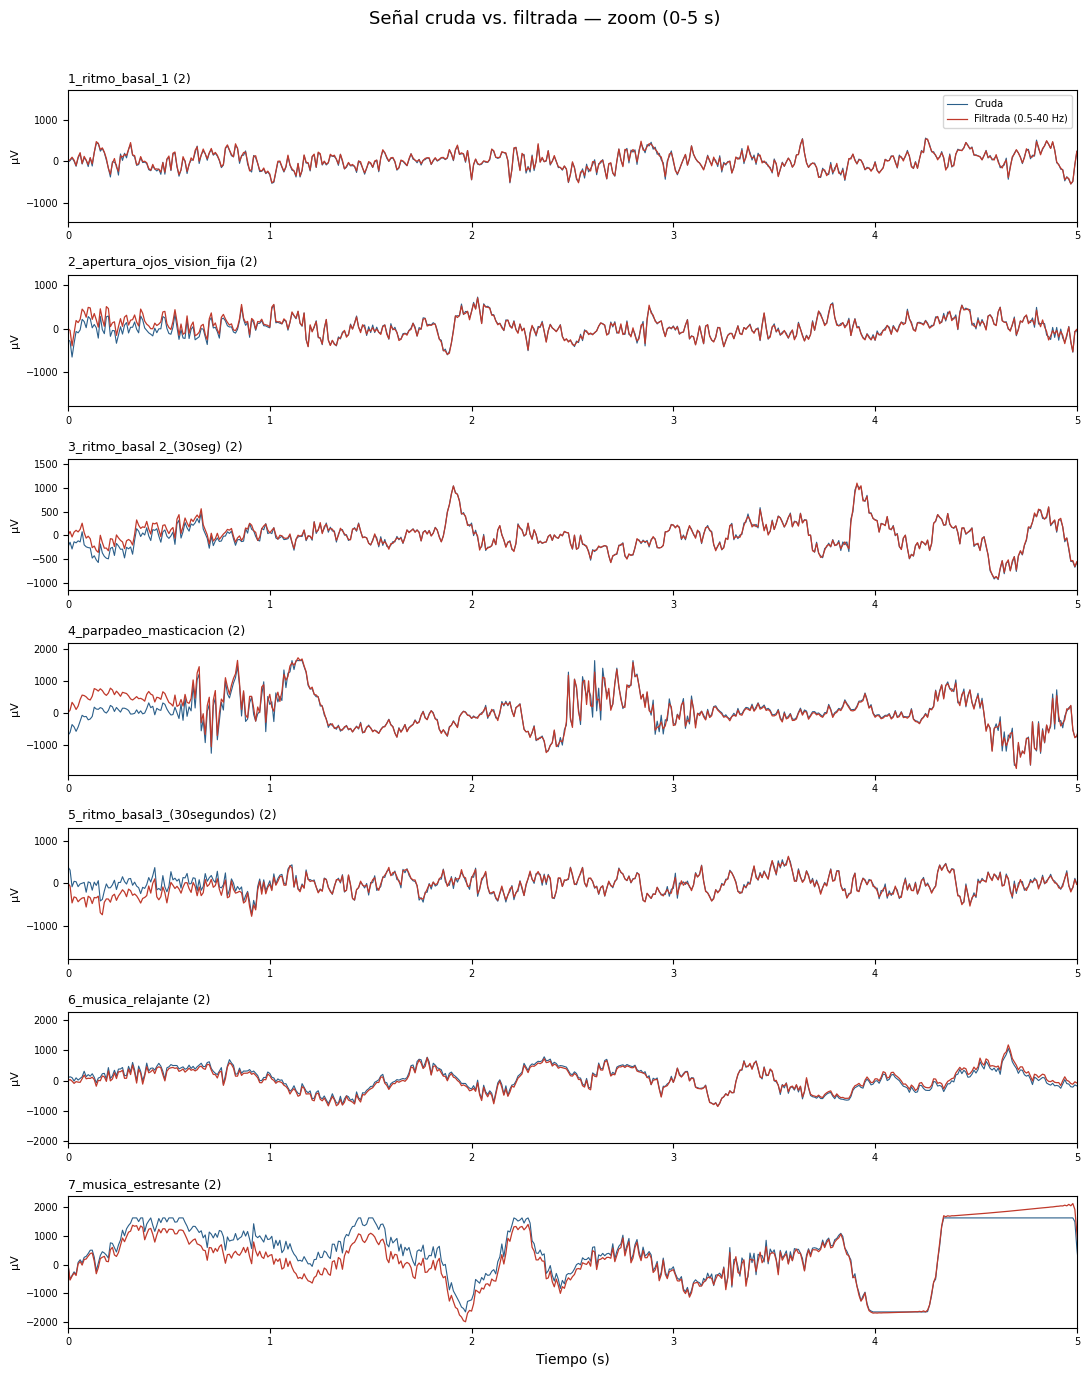

In [15]:
# Zoom en los primeros 5 segundos de cada condición (cruda vs. filtrada),
# para ver con mayor detalle el efecto del filtro pasa-banda.
fig, axes = plt.subplots(len(condiciones), 1, figsize=(11, 14), sharex=False)

for ax, nombre in zip(axes, condiciones.keys()):
    t = condiciones_raw[nombre].times
    cruda_uv = condiciones_raw[nombre].get_data()[0] * 1e6
    filtrada_uv = condiciones[nombre].get_data()[0] * 1e6

    ax.plot(t, cruda_uv, linewidth=0.8, color="#2b5f8a", label="Cruda")
    ax.plot(t, filtrada_uv, linewidth=0.9, color="#c0392b", label="Filtrada (0.5-40 Hz)")
    ax.set_xlim(0, 5)  # AGREGADO: zoom a los primeros 5 segundos
    ax.set_title(nombre, fontsize=9, loc="left")
    ax.set_ylabel("µV", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].legend(loc="upper right", fontsize=7)
axes[-1].set_xlabel("Tiempo (s)")
fig.suptitle("Señal cruda vs. filtrada — zoom (0-5 s)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Actividad 3: Implementar ICA (EMD + FastICA)

In [50]:
!pip install EMD-signal -q

In [51]:
# AGREGADO: reemplaza el montaje de 59 canales + mne.preprocessing.ICA.
# EMD descompone la señal de 1 canal en IMFs (Funciones de Modo Intrínseco,
# cada una capturando una banda de oscilación distinta de la misma señal),
# y estas se tratan como pseudo-canales para aplicar FastICA. A diferencia
# del relleno de ceros, aquí cada pseudo-canal SÍ contiene información real
# y distinta, por lo que ICA no es matemáticamente degenerado.
from PyEMD import EMD
from sklearn.decomposition import FastICA
from scipy.stats import kurtosis
import numpy as np

def emd_ica(señal, max_imf=8, umbral_curtosis=5, random_state=97):
    emd = EMD()
    imfs = emd(señal, max_imf=max_imf)  # (n_imfs, n_muestras)

    ica = FastICA(n_components=imfs.shape[0], random_state=random_state, max_iter=1000)
    fuentes = ica.fit_transform(imfs.T)  # (n_muestras, n_componentes)

    kurts = kurtosis(fuentes, axis=0)
    idx_artefacto = np.where(np.abs(kurts) > umbral_curtosis)[0]

    return {
        "imfs": imfs,
        "ica": ica,
        "fuentes": fuentes,       # (n_muestras, n_componentes)
        "kurtosis": kurts,
        "idx_artefacto": idx_artefacto,
    }

In [52]:
# Aplicar EMD-ICA a las 7 condiciones (usa la señal ya filtrada, Punto 2)
resultados_ica = {}
for nombre, raw_i in condiciones.items():
    señal = raw_i.get_data()[0]
    resultados_ica[nombre] = emd_ica(señal)
    print(f"{nombre}: {resultados_ica[nombre]['imfs'].shape[0]} IMFs, "
          f"curtosis = {np.round(resultados_ica[nombre]['kurtosis'], 2)}, "
          f"artefacto = {resultados_ica[nombre]['idx_artefacto']}")

1_ritmo_basal_1 (2): 6 IMFs, curtosis = [ 2.45  1.56 -0.11  1.05  0.09  1.9 ], artefacto = []
2_apertura_ojos_vision_fija (2): 7 IMFs, curtosis = [ 3.61  3.88  4.57 -0.46  0.56  2.99  5.87], artefacto = [6]
3_ritmo_basal 2_(30seg) (2): 6 IMFs, curtosis = [ 0.84 -0.13  1.43  2.26  0.47  0.5 ], artefacto = []
4_parpadeo_masticacion (2): 8 IMFs, curtosis = [5.09 5.42 0.85 1.32 4.74 3.32 1.08 9.25], artefacto = [0 1 7]
5_ritmo_basal3_(30segundos) (2): 6 IMFs, curtosis = [ 1.48  1.17 -0.51  1.2  -0.4   3.39], artefacto = []
6_musica_relajante (2): 8 IMFs, curtosis = [23.44  4.45  4.96  9.87  5.06 25.76 10.69  6.48], artefacto = [0 3 4 5 6 7]
7_musica_estresante (2): 9 IMFs, curtosis = [6.33 5.74 0.91 2.93 1.31 1.78 0.67 2.81 7.49], artefacto = [0 1 8]


Actividad 4: Graficar e identificar componentes de artefacto

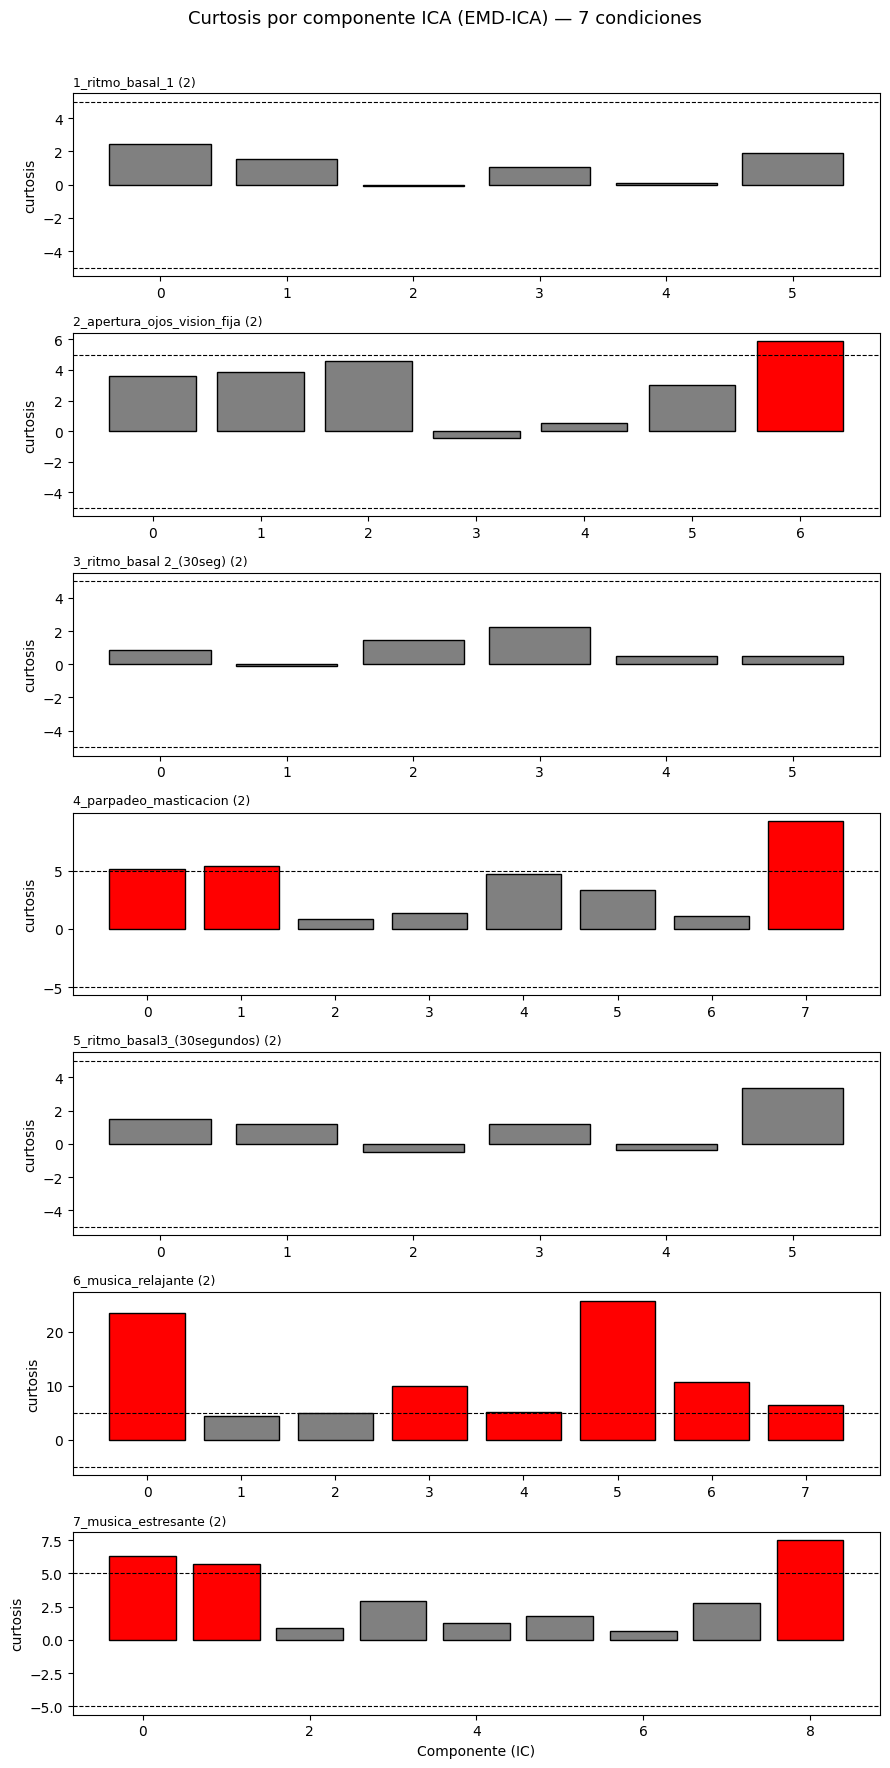

In [53]:
# Gráfica de barras de curtosis por componente, para las 7 condiciones.
# Barras rojas = marcadas como artefacto (|curtosis| > 5).
fig, axes = plt.subplots(len(resultados_ica), 1, figsize=(9, 18))
for ax, (nombre, res) in zip(axes, resultados_ica.items()):
    colores = ["red" if i in res["idx_artefacto"] else "gray"
               for i in range(len(res["kurtosis"]))]
    ax.bar(range(len(res["kurtosis"])), res["kurtosis"], color=colores, edgecolor="black")
    ax.axhline(5, color="black", linestyle="--", linewidth=0.8)
    ax.axhline(-5, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(nombre, fontsize=9, loc="left")
    ax.set_ylabel("curtosis")
axes[-1].set_xlabel("Componente (IC)")
fig.suptitle("Curtosis por componente ICA (EMD-ICA) — 7 condiciones", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

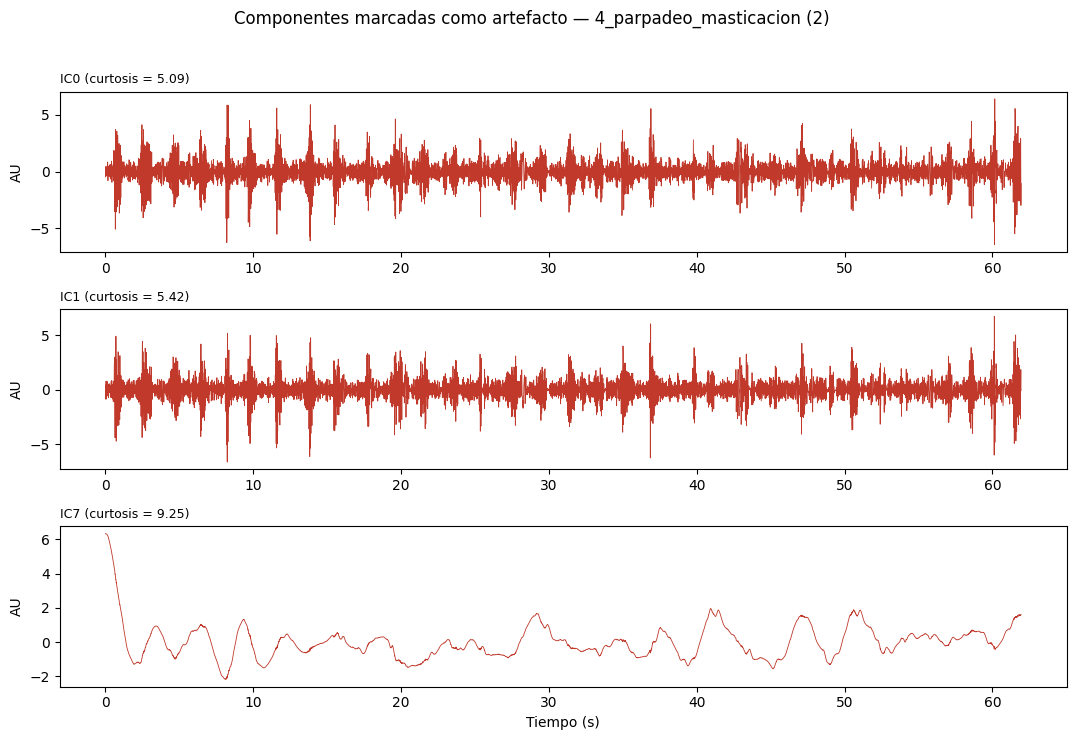

In [54]:
# Series de tiempo de las componentes marcadas como artefacto, para la
# condición de parpadeo/masticación (la más ilustrativa).
nombre_ejemplo = [n for n in condiciones.keys() if "parpadeo" in n][0]
res_ejemplo = resultados_ica[nombre_ejemplo]
raw_ejemplo = condiciones[nombre_ejemplo]
t = raw_ejemplo.times

idx_art = res_ejemplo["idx_artefacto"]
fig, axes = plt.subplots(len(idx_art), 1, figsize=(11, 2.5 * len(idx_art)), squeeze=False)
for ax, idx in zip(axes[:, 0], idx_art):
    ax.plot(t, res_ejemplo["fuentes"][:, idx], linewidth=0.6, color="#c0392b")
    ax.set_title(f"IC{idx} (curtosis = {res_ejemplo['kurtosis'][idx]:.2f})", fontsize=9, loc="left")
    ax.set_ylabel("AU")
axes[-1, 0].set_xlabel("Tiempo (s)")
fig.suptitle(f"Componentes marcadas como artefacto — {nombre_ejemplo}", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Actividad 5: Reconstruir la señal eliminando componentes de artefacto

In [55]:
# Reconstruye la señal poniendo en cero las componentes de artefacto antes
# de invertir la transformación de ICA, y sumando las IMFs resultantes
# (la suma de todas las IMFs reconstruye exactamente la señal original,
# validado: diferencia ~1e-19, precisión de punto flotante).
def reconstruir_limpia(resultado_ica):
    fuentes_limpias = resultado_ica["fuentes"].copy()
    fuentes_limpias[:, resultado_ica["idx_artefacto"]] = 0
    imfs_limpias = resultado_ica["ica"].inverse_transform(fuentes_limpias)  # (n_muestras, n_imfs)
    señal_limpia = imfs_limpias.sum(axis=1)
    return señal_limpia

In [56]:
# Aplicar la reconstrucción a las 7 condiciones
condiciones_corregidas = {}
for nombre, res in resultados_ica.items():
    condiciones_corregidas[nombre] = reconstruir_limpia(res)
    print(f"{nombre}: señal reconstruida ({len(condiciones_corregidas[nombre])} muestras)")

1_ritmo_basal_1 (2): señal reconstruida (6195 muestras)
2_apertura_ojos_vision_fija (2): señal reconstruida (6225 muestras)
3_ritmo_basal 2_(30seg) (2): señal reconstruida (3555 muestras)
4_parpadeo_masticacion (2): señal reconstruida (6195 muestras)
5_ritmo_basal3_(30segundos) (2): señal reconstruida (3315 muestras)
6_musica_relajante (2): señal reconstruida (6480 muestras)
7_musica_estresante (2): señal reconstruida (6255 muestras)


Actividad 6: Comparar señal original vs. corregida

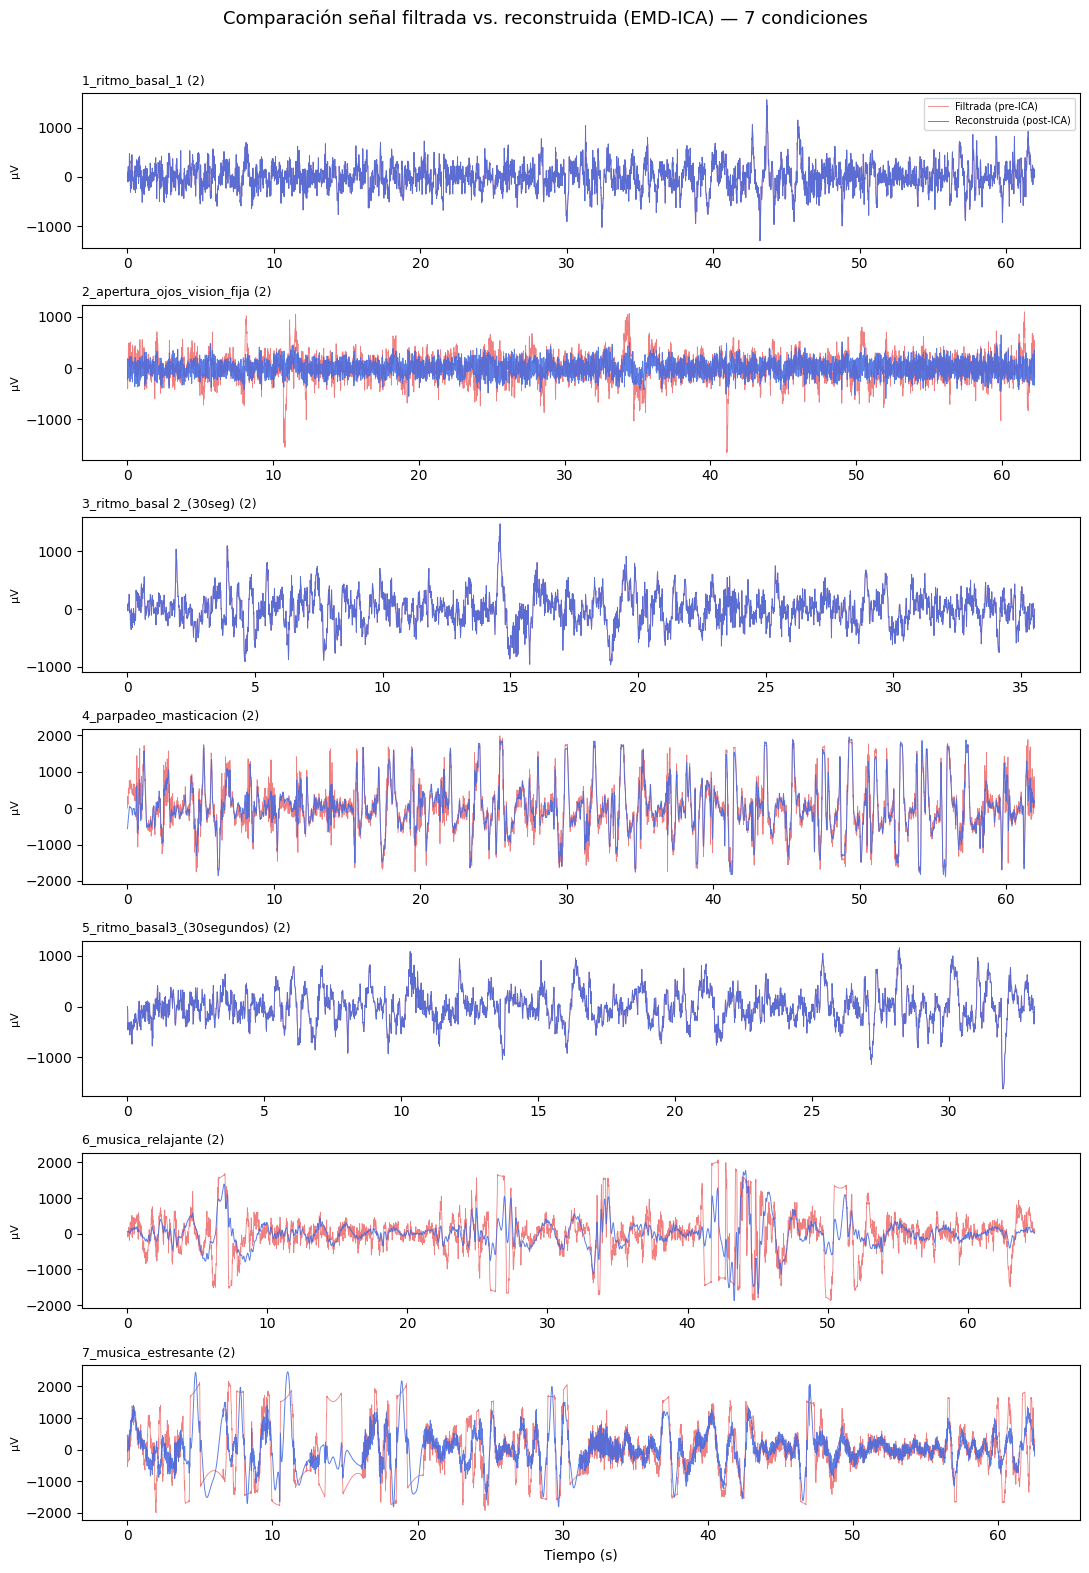

In [57]:
# Comparación visual, para las 7 condiciones
fig, axes = plt.subplots(len(condiciones), 1, figsize=(11, 16))
for ax, nombre in zip(axes, condiciones.keys()):
    t = condiciones[nombre].times
    original_uv = condiciones[nombre].get_data()[0] * 1e6
    limpia_uv = condiciones_corregidas[nombre] * 1e6

    ax.plot(t, original_uv, linewidth=0.6, color="lightcoral", label="Filtrada (pre-ICA)")
    ax.plot(t, limpia_uv, linewidth=0.7, color="royalblue", label="Reconstruida (post-ICA)", alpha=0.85)
    ax.set_title(nombre, fontsize=9, loc="left")
    ax.set_ylabel("µV", fontsize=8)

axes[0].legend(loc="upper right", fontsize=7)
axes[-1].set_xlabel("Tiempo (s)")
fig.suptitle("Comparación señal filtrada vs. reconstruida (EMD-ICA) — 7 condiciones", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Figura 1.** Comparación entre la señal filtrada y la señal reconstruida (EMD-ICA) para las 7 condiciones experimentales.
*(insertar aquí la imagen adjunta)*

In [58]:
# Comparación numérica: diferencia máxima y correlación, por condición
for nombre in condiciones.keys():
    original_uv = condiciones[nombre].get_data()[0] * 1e6
    limpia_uv = condiciones_corregidas[nombre] * 1e6
    diff_max = np.max(np.abs(original_uv - limpia_uv))
    corr = np.corrcoef(original_uv, limpia_uv)[0, 1]
    n_excluidas = len(resultados_ica[nombre]["idx_artefacto"])
    print(f"{nombre}: {n_excluidas} componente(s) excluida(s) | "
          f"diff. máx = {diff_max:.2f} µV | correlación = {corr:.4f}")

1_ritmo_basal_1 (2): 0 componente(s) excluida(s) | diff. máx = 0.00 µV | correlación = 1.0000
2_apertura_ojos_vision_fija (2): 1 componente(s) excluida(s) | diff. máx = 1589.59 µV | correlación = 0.5640
3_ritmo_basal 2_(30seg) (2): 0 componente(s) excluida(s) | diff. máx = 0.00 µV | correlación = 1.0000
4_parpadeo_masticacion (2): 3 componente(s) excluida(s) | diff. máx = 1346.18 µV | correlación = 0.9501
5_ritmo_basal3_(30segundos) (2): 0 componente(s) excluida(s) | diff. máx = 0.00 µV | correlación = 1.0000
6_musica_relajante (2): 6 componente(s) excluida(s) | diff. máx = 2362.92 µV | correlación = 0.6180
7_musica_estresante (2): 3 componente(s) excluida(s) | diff. máx = 2403.54 µV | correlación = 0.7013


##3. Resultados

La comparación entre la señal filtrada (pre-ICA) y la señal reconstruida (post-ICA) para las 7 condiciones se muestra en la Figura 1.


| Condición | IMFs | Componentes excluidas | Curtosis (excluidas) | Diferencia máx. (µV) | Correlación |
|---|---|---|---|---|---|
| Ritmo basal 1 | 6 | 0 | — | 0.00 | 1.0000 |
| Apertura de ojos | 7 | 1 (IC6) | 5.87 | 1589.59 | 0.5640 |
| Ritmo basal 2 (30 s) | 6 | 0 | — | 0.00 | 1.0000 |
| Parpadeo/masticación | 8 | 3 (IC0, IC1, IC7) | 5.09 / 5.42 / 9.25 | 1346.18 | 0.9501 |
| Ritmo basal 3 (30 s) | 6 | 0 | — | 0.00 | 1.0000 |
| Música relajante | 8 | 6 (IC0, IC3, IC4, IC5, IC6, IC7) | 23.44 / 9.87 / 5.06 / 25.76 / 10.69 / 6.48 | 2362.92 | 0.6180 |
| Música estresante | 9 | 3 (IC0, IC1, IC8) | 6.33 / 5.74 / 7.49 | 2403.54 | 0.7013 |

En las tres condiciones basales (reposo), ninguna componente superó el umbral de curtosis, y la señal reconstruida coincide exactamente con la original (correlación = 1.0000, diferencia = 0 µV). En la condición explícitamente diseñada para inducir artefactos (parpadeo/masticación), se excluyeron 3 componentes con curtosis elevada, obteniéndose una señal reconstruida con alta correlación respecto a la original (0.9501) pero con cambios puntuales de gran amplitud (diferencia máxima 1346.18 µV), consistente con la remoción de transitorios aislados. En apertura de ojos, música relajante y música estresante se excluyeron componentes adicionales, con la correlación más baja observada en música relajante (0.6180), donde se excluyó el 75% de las componentes disponibles (6 de 8).


##4.Discusión

Los resultados en las condiciones basales son coherentes con lo esperado: en ausencia de movimiento o estimulación, la señal EEG se aproxima a un proceso de banda ancha sin transitorios de gran amplitud, por lo que ninguna componente debería superar un umbral de no-gaussianidad marcado, y en efecto no se excluyó ninguna. Esto respalda la especificidad del criterio de curtosis en condiciones de baja contaminación.

En la condición de parpadeo/masticación, el método identificó correctamente múltiples componentes de alta curtosis, congruente con la naturaleza impulsiva de estos artefactos (parpadeos como deflexiones lentas de gran amplitud, masticación como actividad muscular de alta frecuencia) [9]. Sin embargo, en música relajante se excluyó una fracción inusualmente alta de componentes (6 de 8, con curtosis de hasta 25.76), lo que resulta llamativo para una condición sin artefactos de movimiento inducidos deliberadamente. Esto sugiere una limitación conocida del criterio de curtosis como métrica única: distribuciones con curtosis elevada no necesariamente corresponden a artefacto, y podrían reflejar respuestas neuronales genuinas ante el estímulo auditivo, o bien una descomposición EMD particularmente sensible al contenido espectral de esa grabación. Esta misma limitación —el uso exclusivo de la curtosis como criterio de discriminación siendo insuficiente en registros con mayor complejidad espectral, como los de estimulación musical— ha sido reportada de forma independiente por otro grupo del curso que empleó una metodología EMD-ICA equivalente sobre datos análogos, lo que refuerza que esta no es una particularidad de nuestros datos sino una limitación inherente al método.

Cabe destacar que, a diferencia de un ICA espacial aplicado sobre electrodos múltiples, esta estrategia no permite generar mapas topográficos (topomapas) de las componentes, ya que las IMFs no poseen una posición física en el cuero cabelludo: son descomposiciones temporales/espectrales de la misma señal de un único electrodo, no mezclas de fuentes captadas en distintas ubicaciones. Por lo tanto, la identificación de artefacto se basa exclusivamente en criterios estadísticos (curtosis) y no puede validarse mediante localización espacial, a diferencia del criterio combinado de pendiente espectral, periferalidad y localización topográfica recomendado en la literatura para ICA multicanal [3,9].

Adicionalmente, la imposibilidad de aplicar un filtro notch efectivo a 60 Hz (por la frecuencia de muestreo de 100 Hz, inferior al doble de esa frecuencia según el teorema de muestreo de Nyquist-Shannon [8]) implica que cualquier interferencia de red eléctrica en ese rango no pudo ser removida de forma confiable mediante filtrado lineal, y debió, en cambio, ser potencialmente capturada o no por la descomposición EMD-ICA junto con el resto de la señal.

##5. Conclusiones

Se implementó un flujo de procesamiento de EEG de un solo canal basado en la descomposición EMD seguida de ICA (FastICA) sobre las IMFs resultantes, utilizando la curtosis como criterio cuantitativo para la identificación de componentes artefactuales. El método demostró sensibilidad adecuada en la condición diseñada explícitamente para inducir artefactos (parpadeo/masticación), sin remover componentes en los registros de reposo, lo cual respalda su validez como estrategia de separación de fuentes en registros de un único canal, superando la limitación fundamental de que ICA espacial convencional requiere múltiples electrodos simultáneos. No obstante, se identificó una limitación relevante en la condición de música relajante, donde la fracción inusualmente alta de componentes excluidas sugiere que el umbral fijo de curtosis (|curtosis| > 5) puede no ser óptimo para todas las condiciones experimentales, y que trabajos futuros deberían explorar criterios complementarios (pendiente espectral, análisis de estacionariedad) o umbrales adaptativos, además de evaluar el método con montajes de mayor número de canales reales que permitan validación espacial de las componentes identificadas.

##6. Referencias

1. Cecotti H, Eckstein M, Giesbrecht B. Single-trial classification of event-related potentials in rapid serial visual presentation tasks using supervised spatial filtering. IEEE Trans Neural Netw Learn Syst. 2014;25(11):2030-2042. doi:10.1109/TNNLS.2014.2302898

2. Jung TP, Makeig S, Humphries C, Lee TW, McKeown MJ, Iragui V, et al. Removing electroencephalographic artifacts by blind source separation. Psychophysiology. 2000;37(2):163-178. doi:10.1111/1469-8986.3720163

3. Dharmaprani D, Nguyen HK, Lewis TW, DeLosAngeles D, Willoughby JO, Pope KJ. A comparison of independent component analysis algorithms and measures to discriminate between EEG and artifact components. In: Proceedings of the 38th Annual International Conference of the IEEE Engineering in Medicine and Biology Society (EMBC); 2016 Aug 16-20; Orlando, FL, USA. p. 825-828. doi:10.1109/EMBC.2016.7590828

4. Huang NE, Shen Z, Long SR, Wu MC, Shih HH, Zheng Q, et al. The empirical mode decomposition and the Hilbert spectrum for nonlinear and non-stationary time series analysis. Proc R Soc Lond A. 1998;454(1971):903-995. doi:10.1098/rspa.1998.0193

5. Hyvärinen A, Oja E. Independent component analysis: algorithms and applications. Neural Netw. 2000;13(4-5):411-430. doi:10.1016/S0893-6080(00)00026-5

6. Mijović B, De Vos M, Gligorijević I, Taelman J, Van Huffel S. Source separation from single-channel recordings by combining empirical-mode decomposition and independent component analysis. IEEE Trans Biomed Eng. 2010;57(9):2188-2196. doi:10.1109/TBME.2010.2051440

7. PLUX Wireless Biosignals. BITalino (r)evolution Home Guide: Electroencephalography (EEG). Lisbon: PLUX; 2021.

8. Shannon CE. Communication in the presence of noise. Proc IRE. 1949;37(1):10-21. doi:10.1109/JRPROC.1949.232969

9. Delorme A, Sejnowski T, Makeig S. Enhanced detection of artifacts in EEG data using higher-order statistics and independent component analysis. Neuroimage. 2007;34(4):1443-1449. doi:10.1016/j.neuroimage.2006.11.004